### Logistic regression

In [23]:
import matplotlib.pyplot as plt
import numpy as np

In [24]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_6180/2885621977.py:7: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma (z)$')


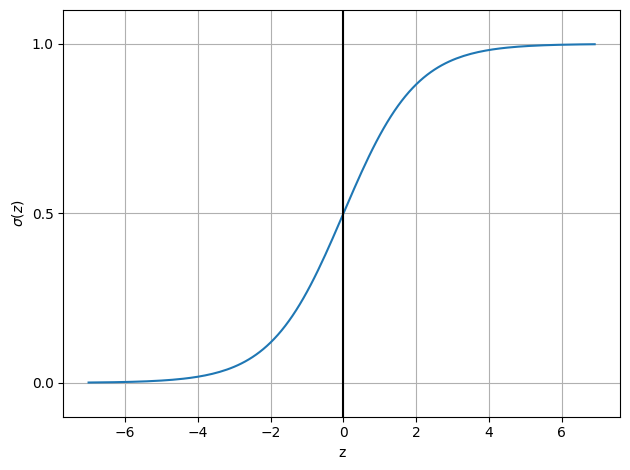

In [25]:
z = np.arange(-7, 7, 0.1)
sigma_z = sigmoid(z)
plt.plot(z, sigma_z)
plt.axvline(0.0, color='k')
plt.ylim(-0.1, 1.1)
plt.xlabel('z')
plt.ylabel('$\sigma (z)$')
plt.yticks([0.0, 0.5, 1.0])
plt.tight_layout()
plt.grid()
plt.show()

Loss function of classifying a single training example

<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_6180/1280745820.py:14: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('$\sigma (z)$')


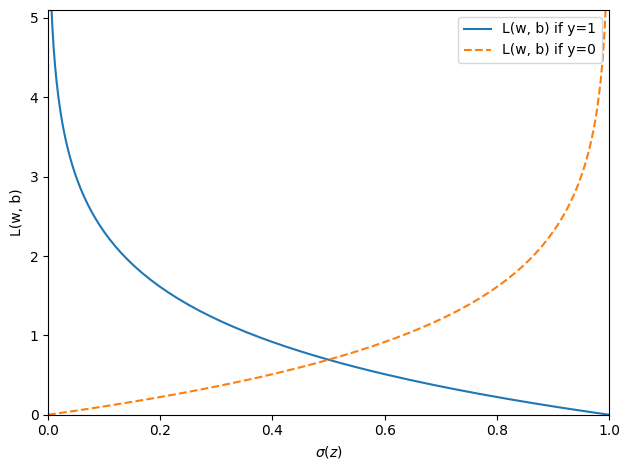

In [26]:
def loss_1(z):
    return -np.log(sigmoid(z))
def loss_0(z):
    return -np.log(1-sigmoid(z))

z = np.arange(-10, 10, 0.1)
sigma_z = sigmoid(z)
c1 = [loss_1(x) for x in z]
plt.plot(sigma_z, c1, label='L(w, b) if y=1')
c0 = [loss_0(x) for x in z]
plt.plot(sigma_z, c0, linestyle='--', label='L(w, b) if y=0')
plt.ylim(0.0, 5.1)
plt.xlim([0,1])
plt.xlabel('$\sigma (z)$')
plt.ylabel('L(w, b)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

We can see that the loss approaches 0 if we correcly predict that an example belogs to class 1/0 for the own loss function

In [27]:
class LogisticRegrassionGD:
    def __init__(self, eta:float=0.01, n_iter:int=50, random_state:int=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state
    

    def fit(self, X:np.array, y:np.array):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.float64(0.)
        self.losses_ = []

        for _ in range(self.n_iter):
            net_input = self.net_input(X)
            output = self.activation(net_input)
            errors = y - output
            self.w_ += self.eta * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * errors.sum() / X.shape[0]
            loss = (-y.dot(np.log(output))
                    - ((1-y).dot(np.log(1-output))) 
                    / X.shape[0])
            self.losses_.append(loss)
        return self
            


    def net_input(self, X:np.array):
        return np.dot(X, self.w_) + self.b_
    
    def activation(self, z:float):
        return 1. / (1. + np.exp(-np.clip(z, -250, 250)))
    
    def predict(self, X:np.array):
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)


In [28]:
from sklearn import datasets
from sklearn.preprocessing import StandardScaler

iris = datasets.load_iris()
X = iris.data[:, [2,3]]
y = iris.target
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    
    # stratify=y: stratifications means that the function
    #returns training and test subsets that have the same
    #proportions of class labels as the imput dataset
    X, y, test_size=0.3, random_state=1, stratify=y
)

sc = StandardScaler()
sc.fit(X_train)

X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)


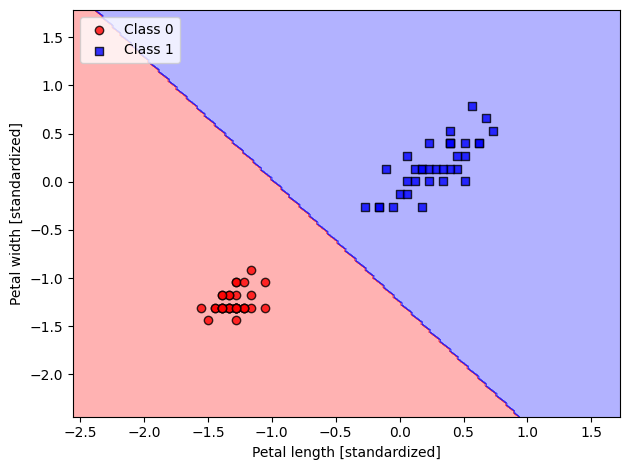

In [29]:
from plot_decision_regresion import plot_decision_regions

X_train_01_subset = X_train_std[(y_train == 0) | (y_train == 1 )]
y_train_01_subset = y_train[(y_train == 0) | (y_train == 1 )]
lrgd = LogisticRegrassionGD(eta=0.3,
                            n_iter=1000,
                            random_state=1)
lrgd.fit(X_train_01_subset, y_train_01_subset)
plot_decision_regions(X=X_train_01_subset,
                      y=y_train_01_subset,
                      classifier=lrgd)
plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

/home/adrian-pc/yes/envs/optim-2/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


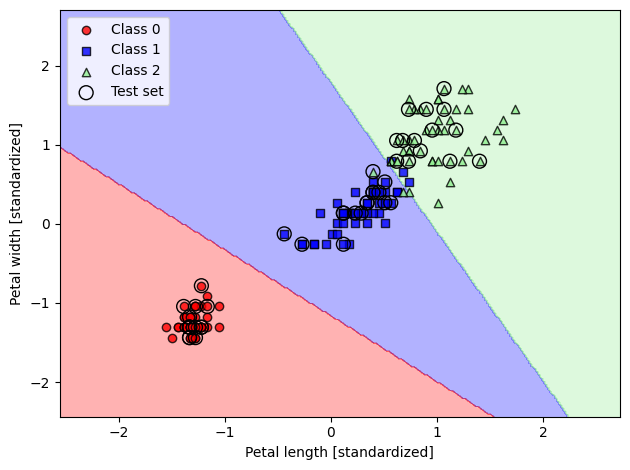

In [30]:
from sklearn.linear_model import LogisticRegression
from plot_decision_regresion import plot_decision_regions

X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))
lr = LogisticRegression(C=100.0, solver='lbfgs',multi_class='multinomial')
lr.fit(X_train_std, y_train)
plot_decision_regions(X=X_combined_std,
                      y=y_combined,
                      classifier=lr,
                      test_idx=range(105,150))
plt.xlabel('Petal length [standardized]')
plt.ylabel('Petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

Predict probability

In [31]:
lr.predict_proba(X_test_std[:3, :])

array([[9.37368464e-13, 3.91458193e-04, 9.99608542e-01],
       [9.93631074e-01, 6.36892585e-03, 1.20730798e-15],
       [9.98707332e-01, 1.29266792e-03, 1.82177043e-17]])

In [32]:
# The column-wise sum in each row is 1
lr.predict_proba(X_test_std[:3, :]).sum(axis=1)

array([1., 1., 1.])

In [33]:
# we can get the predicted class labels by identifying the largest column in each row
lr.predict_proba(X_test_std[:3, :]).argmax(axis=1)

array([2, 0, 0])

In [34]:
# predicted class labels using sklearn
lr.predict(X_test_std[:3, :])

array([2, 0, 0])

In [35]:
lr.predict(X_test_std[0, :].reshape(1, -1))
# sklearn expects a two-dimensional array as data input
# so we have to convert a single row in two dimensional
# data array

array([2])

Visualization of L2 regularization for different C values

/home/adrian-pc/yes/envs/optim-2/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/adrian-pc/yes/envs/optim-2/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/adrian-pc/yes/envs/optim-2/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/adrian-pc/yes/envs/optim-2/lib/python3.13/site-packages/sklearn/linear_mo

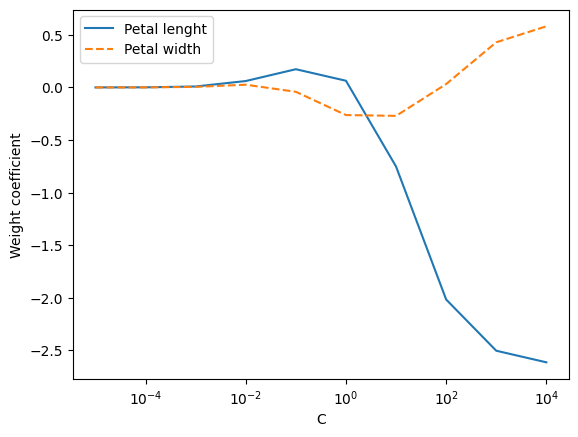

In [40]:
weights, params = [], []
for c in np.arange(-5, 5):
    lr = LogisticRegression(C=10.**c,
                            multi_class='multinomial')
    lr.fit(X_train_std, y_train)
    weights.append(lr.coef_[1])
    params.append(10.**c)
weights = np.asarray(weights)
plt.plot(params, weights[:,0],
         label='Petal lenght')
plt.plot(params,weights[:, 1], linestyle='--',
         label='Petal width')
plt.ylabel('Weight coefficient')
plt.xlabel('C')
plt.legend(loc='upper left')
plt.xscale('log')
plt.show()

We have to be careful when adjusting the regularization strength.If it is too high and weight coefficients approach zero, the model can perform very poorly due to underfitting.